# Foundations of Data Analysis with Python

### Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading data

### First look at the datasets

Questions:
- What tables do we have?
- What might each be used for?
- Which one relates to revenue?

In [66]:
customers.head()

,customer_id,age,gender,country,acquisition_channel,signup_date
0,1,56.0,Other,Germany,referral,2019-07-21
1,2,38.0,Other,Netherlands,email,2022-03-04
2,3,28.0,Other,Australia,referral,2024-05-21
3,4,19.0,Female,Australia,paid_search,2022-06-28
4,5,38.0,Female,Australia,referral,2024-07-17


In [36]:
transactions.head()

,transaction_id,customer_id,product_category,purchase_value,discount_used,purchase_date
0,1,8141,home,74.32,0,2023-09-05
1,2,1297,fashion,17.51,0,2019-08-07
2,3,7930,toys,39.96,1,2020-02-07
3,4,2426,electronics,43.79,0,2020-10-02
4,5,6614,fashion,187.01,0,2023-09-15


In [38]:
sessions.head()

,session_id,customer_id,pages_viewed,time_on_site,device_type,traffic_source,session_date,converted
0,1,9716,8,271.238207,desktop,organic,2022-06-18,0
1,2,4617,5,257.386842,mobile,social,2020-07-03,0
2,3,1506,4,289.679888,tablet,paid,2020-12-12,0
3,4,3869,5,146.543376,mobile,direct,2023-09-12,0
4,5,6245,3,339.228209,mobile,email,2019-04-02,0


### Dataset structure

Questions:
- Which table is biggest?
- What might that mean?

In [67]:
customers.shape

(10000, 6)

In [40]:
transactions.shape

(45000, 6)

In [41]:
sessions.shape

(70100, 8)

### Column overview

In [68]:
customers.columns

Index(['customer_id', 'age', 'gender', 'country', 'acquisition_channel',
       'signup_date'],
      dtype='object')

In [69]:
transactions.columns

Index(['transaction_id', 'customer_id', 'product_category', 'purchase_value',
       'discount_used', 'purchase_date'],
      dtype='object')

### Missing values

In [ ]:
customers.isnull().sum()

customer_id              0
age                    807
gender                   0
country                  0
acquisition_channel      0
signup_date              0
dtype: int64

In [45]:
sessions.isnull().sum()

session_id          0
customer_id         0
pages_viewed        0
time_on_site        0
device_type       500
traffic_source      0
session_date        0
converted           0
dtype: int64

### Descriptive statistics

Ask:
- What is average purchase?
- What looks unusual?

In [46]:
transactions.describe()

,transaction_id,customer_id,purchase_value,discount_used
count,45000.000000,45000.000000,45000.000000,45000.000000
mean,22500.500000,4974.805022,75.842704,0.300578
std,12990.525394,2893.494174,59.088617,0.458514
min,1.000000,2.000000,0.390000,0.000000
25%,11250.750000,2462.000000,35.440000,0.000000
50%,22500.500000,4960.000000,62.990000,0.000000
75%,33750.250000,7479.000000,101.032500,1.000000
max,45000.000000,10000.000000,1995.280000,1.000000


### Distribution of purchase value

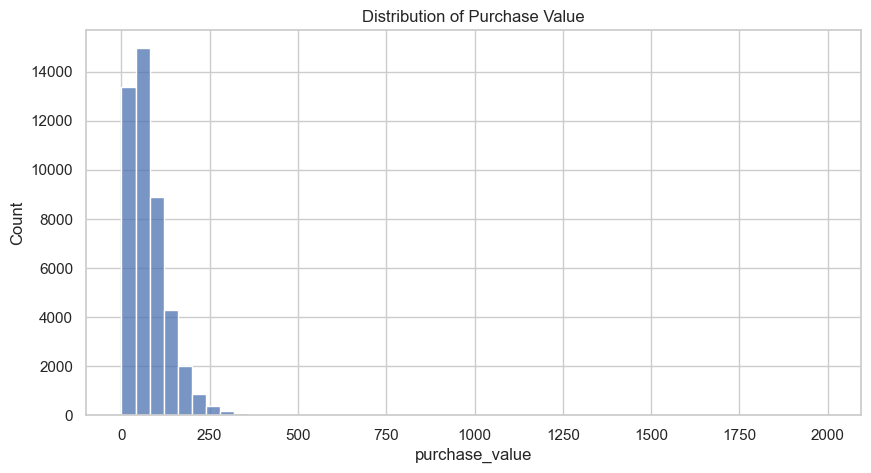

In [73]:
plt.figure(figsize=(10,5))
sns.histplot(transactions["purchase_value"], bins=50)
plt.title("Distribution of Purchase Value")
plt.show()

### Outliers

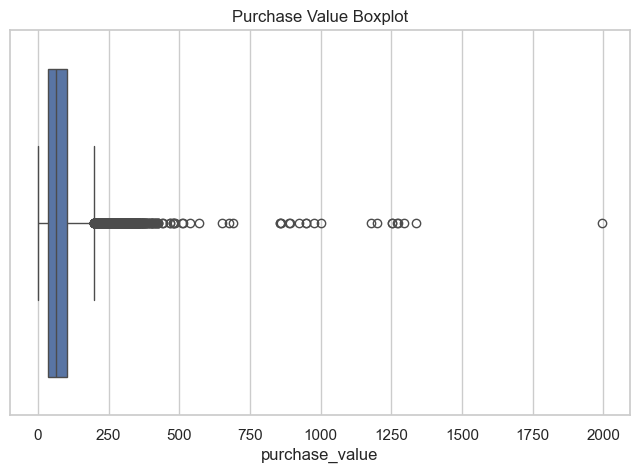

In [56]:
plt.figure(figsize=(8,5))
sns.boxplot(x=transactions["purchase_value"])
plt.title("Purchase Value Boxplot")
plt.show()

What might extreme values represent?

### Group exploration

Mean purchase by category

In [ ]:
transactions.groupby("product_category")["purchase_value"].mean().sort_values(ascending=False)

product_category
beauty         76.701992
electronics    74.536697
fashion        76.458847
home           76.741071
sports         75.647749
toys           74.931584
Name: purchase_value, dtype: float64

Mean purchase by discount usage

In [75]:
transactions.groupby("discount_used")["purchase_value"].mean()

discount_used
0    80.762030
1    64.395796
Name: purchase_value, dtype: float64

### Customer exploration

In [59]:
customers["country"].value_counts()

country
Canada         1297
Spain          1280
UK             1268
France         1254
Netherlands    1244
Australia      1239
US             1238
Germany        1180
Name: count, dtype: int64

In [60]:
customers.groupby("country")["age"].mean().sort_values()

country
Canada         43.168614
UK             43.266039
US             43.427441
Netherlands    43.428322
Spain          43.452766
France         43.514834
Germany        43.717190
Australia      44.613835
Name: age, dtype: float64

### Behavioural insight

In [83]:
merged = transactions.merge(customers, on="customer_id")

merged.groupby(["gender", "product_category"])["purchase_value"].max()

#merged_1 = transactions.merge(customers, on="customer_id")

gender  product_category
Female  beauty               949.52
        electronics          424.12
        fashion             1269.68
        home                 362.28
        sports              1275.28
        toys                 423.84
Male    beauty               691.52
        electronics         1000.64
        fashion             1177.92
        home                1995.28
        sports               860.00
        toys                1253.68
Other   beauty               976.96
        electronics          513.76
        fashion              569.28
        home                1294.00
        sports               536.08
        toys                1201.12
Name: purchase_value, dtype: float64

### Thinking prompts
- Who are high-value customers?
- What would you investigate next?
- What looks surprising?
- What might drive revenue?